Для набора данных,  выбранного в первой лабораторной работе,  необходимо провести кластеризацию при помощи двух методов, взятых из следующих разных групп:
- метода k-средних (или альтернативного из группы, основанной на расстояниях между точками),
- одним из методов иерархической кластеризации.

Для метода из первой и третьей групп необходимо выбрать количество кластеров с использованием одного из методов (метод локтя, индекс Дана, индекс Дэвиса-Болдуина, индекс Калинского-Гарабача, метод силуэта, RAND - обязателен при наличии целевой переменной, кофенетическая корреляция)

Критерии оценивания:

1. применение первого метода кластеризации (3 очка);
2. применение второго метода кластеризации (3 очка);
3. оценка точности кластеризации (2 очка);
4. подбор гиперпараметров (1 очко);
5. визуализация результатов кластеризации (1 очко).

Дополнение: Объединить чистые класстеры. Сделать уточннение, что бинарная метрика мало что даст
Индекс Джини

In [32]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, adjusted_rand_score
import xgboost as xgb

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import pairwise_distances_argmin

from scipy.cluster.hierarchy import linkage as scipy_linkage, fcluster

## Читаем БД

In [33]:
df = pd.read_csv('../data/adult11.csv')

for column in df.columns:
    unique_vals = df[column].unique().tolist()
    print(f"Столбец '{column}': {unique_vals}")
    
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'salary']

Столбец 'age': [25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20, 37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30, 47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77, 80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85, 76, 84, 89, 88, 87, 86]
Столбец 'workclass': ['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Столбец 'fnlwgt': [226802, 89814, 336951, 160323, 103497, 198693, 227026, 104626, 369667, 104996, 184454, 212465, 82091, 299831, 279724, 346189, 444554, 128354, 60548, 85019, 107914, 238588, 132015, 220931, 205947, 432824, 236427, 134446, 99516, 109282, 106444, 186651, 188274, 258120, 43311, 191846, 403681, 248446, 269430, 257509, 136384, 120277, 465326, 103634, 138371, 242832, 290208, 186272, 201062, 131916, 54440, 280215, 214399, 54164, 219446, 110677, 145985, 382078, 170721, 269705, 101135, 118429, 31208, 281384, 171807, 109912, 4453

## Чистим

In [34]:
df_clean = df.replace(['', '?'], np.nan).copy()

imputer = SimpleImputer(strategy='most_frequent')
df_clean['workclass'] = pd.Series(imputer.fit_transform(df[['workclass']]).ravel())
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

## Стандартизация

In [35]:
df_transformed = df_clean.copy()

for col in numeric_features:
    df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce')

means = df_transformed[numeric_features].mean(axis=0)
stds = df_transformed[numeric_features].std(axis=0)
df_transformed[numeric_features] = (df_transformed[numeric_features] - means) / stds

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_transformed[col] = le.fit_transform(df_transformed[col].astype(str))
    label_encoders[col] = le

print("\nПосле стандартизации (M=0, D=1):")
print(df_transformed[numeric_features].round(3))


После стандартизации (M=0, D=1):
         age  fnlwgt  education-num  capital-gain  capital-loss  \
0     -0.995   0.352         -1.197        -0.145        -0.217   
1     -0.047  -0.946         -0.419        -0.145        -0.217   
2     -0.776   1.395          0.748        -0.145        -0.217   
3      0.391  -0.278         -0.030         0.887        -0.217   
4     -1.506  -0.816         -0.030        -0.145        -0.217   
...      ...     ...            ...           ...           ...   
48837 -0.849   0.640          0.748        -0.145        -0.217   
48838  0.099  -0.334         -0.419        -0.145        -0.217   
48839  1.412  -0.358         -0.419        -0.145        -0.217   
48840 -1.214   0.112         -0.419        -0.145        -0.217   
48841  0.974   0.930         -0.419         1.871        -0.217   

       hours-per-week  
0              -0.034  
1               0.773  
2              -0.034  
3              -0.034  
4              -0.841  
...              

## Выборка

In [36]:
X = df_transformed.drop('salary', axis=1)
y = df_transformed['salary']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Размер X: (48842, 14)
Размер y: (48842,)


### k-means

### Метод локтя

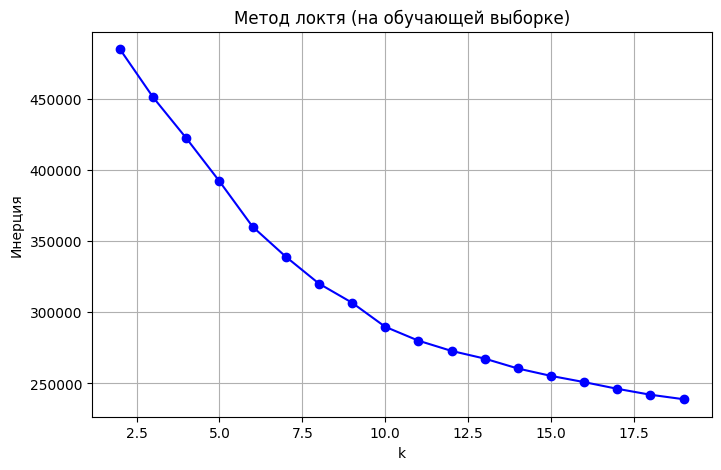

Выбрано k = 10


In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

possible_k = range(2, 20)
inertias = []
for k in possible_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(possible_k, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Инерция')
plt.title('Метод локтя (на обучающей выборке)')
plt.grid(True)
plt.show()

best_k = int(input("Введите выбранное число кластеров: "))
print(f"Выбрано k = {best_k}")

### Подбор гиперпараметров

In [38]:
best_inertia = np.inf
best_params = {}
param_grid = {
    'init': ['k-means++', 'random'],
    'n_init': [5, 10, 15],
    'max_iter': [200, 300, 500]
}
for init in param_grid['init']:
    for n_init in param_grid['n_init']:
        for max_iter in param_grid['max_iter']:
            km = KMeans(n_clusters=best_k, init=init, n_init=n_init,
                        max_iter=max_iter, random_state=42)
            km.fit(X_train_scaled)
            if km.inertia_ < best_inertia:
                best_inertia = km.inertia_
                best_params = {'init': init, 'n_init': n_init, 'max_iter': max_iter}
print("Лучшие гиперпараметры:", best_params)

Лучшие гиперпараметры: {'init': 'k-means++', 'n_init': 15, 'max_iter': 200}


### Кластеризация

In [39]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, **best_params)
clusters_train = kmeans_final.fit_predict(X_train_scaled)

# Предсказание кластеров для тестовой выборки
clusters_test = kmeans_final.predict(X_test_scaled)


### Оценка точности

Adjusted Rand Index (RAND) на тесте: 0.0164


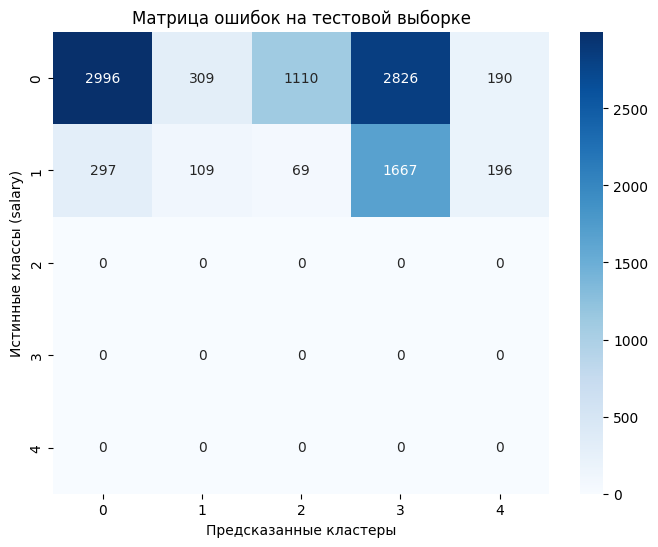

In [49]:
rand = adjusted_rand_score(y_test, clusters_test)
print(f"Adjusted Rand Index (RAND) на тесте: {rand:.4f}")

conf = confusion_matrix(y_test, clusters_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные кластеры')
plt.ylabel('Истинные классы (salary)')
plt.title('Матрица ошибок на тестовой выборке')
plt.show()

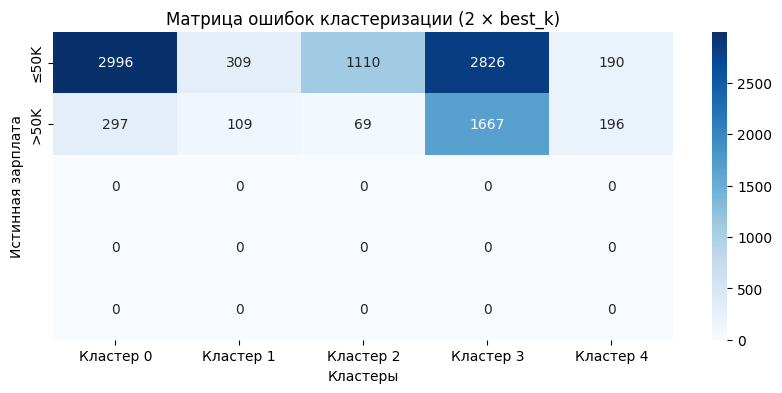

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

clusters_test = kmeans_final.predict(X_test_scaled)
cm = confusion_matrix(y_test, clusters_test)

plt.figure(figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Кластер {i}' for i in range(cm.shape[1])],
            yticklabels=['≤50K', '>50K'])
plt.xlabel('Кластеры')
plt.ylabel('Истинная зарплата')
plt.title('Матрица ошибок кластеризации (2 × best_k)')
plt.show()

### Визуализация

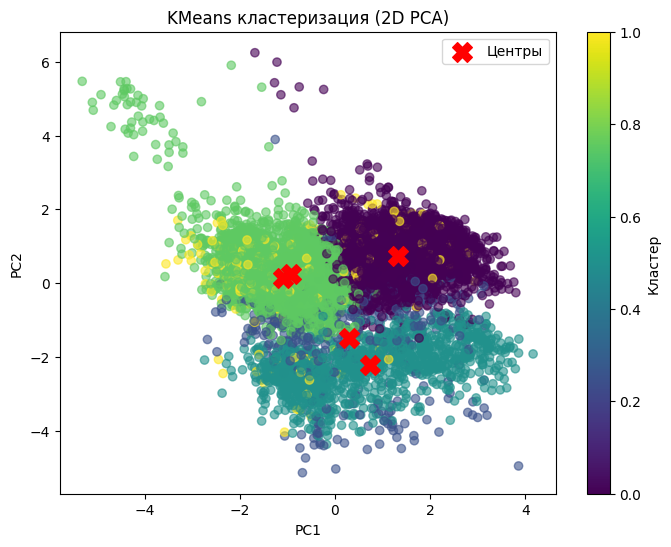

In [41]:
# 2D PCA визуализация
pca_2d = PCA(n_components=2)
X_test_pca_2d = pca_2d.fit_transform(X_test_scaled)
centers_pca_2d = pca_2d.transform(kmeans_final.cluster_centers_)

# Создание DataFrame для точек
df_points_2d = pd.DataFrame(X_test_pca_2d, columns=['PC1', 'PC2'])
df_points_2d['cluster'] = clusters_test.astype(str)

# Создание DataFrame для центров
df_centers_2d = pd.DataFrame(centers_pca_2d, columns=['PC1', 'PC2'])
df_centers_2d['cluster'] = [f'Центр {i}' for i in range(len(centers_pca_2d))]

# Альтернатива с matplotlib (статичный)
plt.figure(figsize=(8,6))
plt.scatter(X_test_pca_2d[:,0], X_test_pca_2d[:,1], c=clusters_test, cmap='viridis', alpha=0.6)
plt.scatter(centers_pca_2d[:,0], centers_pca_2d[:,1], c='red', marker='X', s=200, label='Центры')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans кластеризация (2D PCA)')
plt.colorbar(label='Кластер')
plt.legend()
plt.show()

### Визуализация 3D

In [42]:
pca_3d = PCA(n_components=3)
X_test_pca_3d = pca_3d.fit_transform(X_test_scaled)
centers_pca_3d = pca_3d.transform(kmeans_final.cluster_centers_)

# Создаём DataFrame для точек
df_points = pd.DataFrame(X_test_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_points['cluster'] = clusters_test.astype(str)

# Создаём DataFrame для центров
df_centers = pd.DataFrame(centers_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_centers['cluster'] = [f'Центр {i}' for i in range(len(centers_pca_3d))]

fig = px.scatter_3d(df_points, x='PC1', y='PC2', z='PC3', color='cluster',
                    opacity=0.3, size_max=3, title='KMeans кластеризация (3D)')
# Добавляем центры
fig.add_trace(go.Scatter3d(x=df_centers['PC1'], y=df_centers['PC2'], z=df_centers['PC3'],
                           mode='markers', marker=dict(size=8, color='red', symbol='x'),
                           name='Центры'))
fig.show()

# Agglomerative Classtering

### ARI

In [57]:
# Строим linkage-матрицу один раз (самое долгое)
linked = linkage(X_train_scaled, method='ward')

possible_k = range(2, 30)
rand_scores = []

for k in possible_k:
    labels = fcluster(linked, t=k, criterion='maxclust')
    rand = adjusted_rand_score(y_train, labels)
    rand_scores.append(rand)
    print(f"k={k}, RAND={rand:.4f}")

best_k = possible_k[np.argmax(rand_scores)]
print(f"Оптимальное k по RAND: {best_k}")

plt.plot(possible_k, rand_scores, 'go-')
plt.xlabel('k')
plt.ylabel('Adjusted Rand Index')
plt.title('Выбор k по RAND (обучающая выборка)')
plt.grid()
plt.show()

TypeError: 'str' object is not callable

### Подбор гиперпараметров

In [44]:
linkage_options = ['ward', 'complete', 'average', 'single']
metric = 'euclidean'

best_ari = -1
best_linkage = None

print("Подбор гиперпараметров (linkage) по ARI на обучающей выборке:")
for linkage in linkage_options:
    model = AgglomerativeClustering(n_clusters=best_k, linkage=linkage, metric=metric)
    
    labels = model.fit_predict(X_train_scaled)
    ari = adjusted_rand_score(y_train, labels)
    print(f"linkage = {linkage:<10} ARI = {ari:.4f}")
    
    if ari > best_ari:
        best_ari = ari
        best_linkage = linkage

print(f"\nЛучший linkage: {best_linkage} (ARI = {best_ari:.4f})")

Подбор гиперпараметров (linkage) по ARI на обучающей выборке:
linkage = ward       ARI = 0.1228
linkage = complete   ARI = 0.0769
linkage = average    ARI = 0.0208
linkage = single     ARI = 0.0208

Лучший linkage: ward (ARI = 0.1228)


### Оценка точности


Adjusted Rand Index (RAND) на тесте: 0.0646


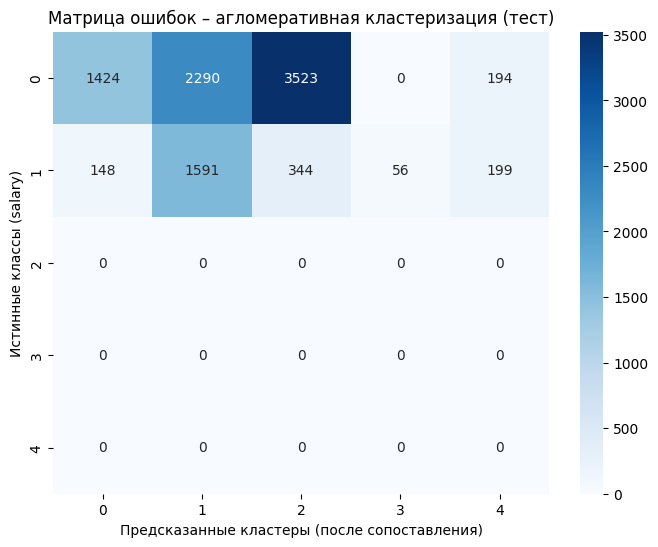

In [55]:
final_model = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage, metric='euclidean')
cluster_train = final_model.fit_predict(X_train_scaled)

centroids = np.array([X_train_scaled[cluster_train == i].mean(axis=0) for i in range(best_k)])

cluster_test = pairwise_distances_argmin(X_test_scaled, centroids)

ari_test = adjusted_rand_score(y_test, cluster_test)
print(f"\nAdjusted Rand Index (RAND) на тесте: {ari_test:.4f}")

cm = confusion_matrix(y_test, cluster_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные кластеры (после сопоставления)')
plt.ylabel('Истинные классы (salary)')
plt.title('Матрица ошибок – агломеративная кластеризация (тест)')
plt.show()

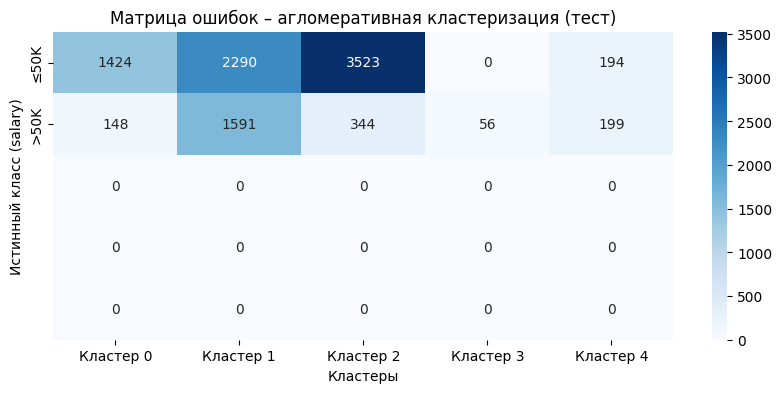

In [54]:
cluster_test = pairwise_distances_argmin(X_test_scaled, centroids)
cm = confusion_matrix(y_test, cluster_test)

plt.figure(figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Кластер {i}' for i in range(cm.shape[1])],
            yticklabels=['≤50K', '>50K'])
plt.xlabel('Кластеры')
plt.ylabel('Истинный класс (salary)')
plt.title('Матрица ошибок – агломеративная кластеризация (тест)')
plt.show()

### Визуализация

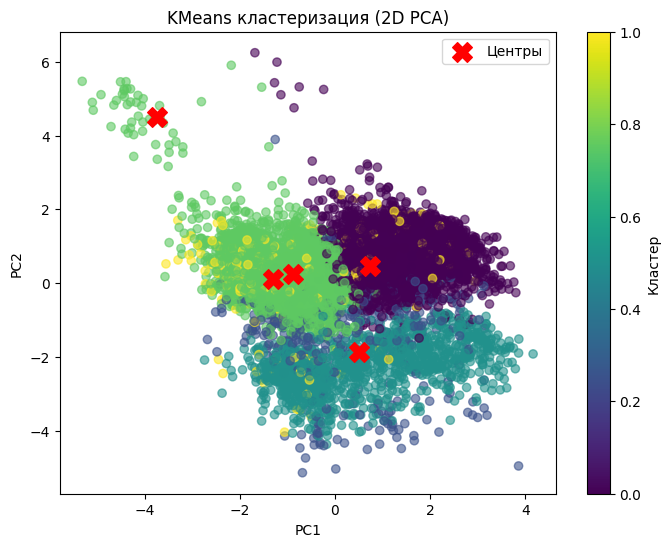

In [46]:
# 2D PCA визуализация
pca_2d = PCA(n_components=2)
X_test_pca_2d = pca_2d.fit_transform(X_test_scaled)
centers_pca_2d = pca_2d.transform(centroids)

# Создание DataFrame для точек
df_points_2d = pd.DataFrame(X_test_pca_2d, columns=['PC1', 'PC2'])
df_points_2d['cluster'] = clusters_test.astype(str)

# Создание DataFrame для центров
df_centers_2d = pd.DataFrame(centers_pca_2d, columns=['PC1', 'PC2'])
df_centers_2d['cluster'] = [f'Центр {i}' for i in range(len(centers_pca_2d))]

# Альтернатива с matplotlib (статичный)
plt.figure(figsize=(8,6))
plt.scatter(X_test_pca_2d[:,0], X_test_pca_2d[:,1], c=clusters_test, cmap='viridis', alpha=0.6)
plt.scatter(centers_pca_2d[:,0], centers_pca_2d[:,1], c='red', marker='X', s=200, label='Центры')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans кластеризация (2D PCA)')
plt.colorbar(label='Кластер')
plt.legend()
plt.show()

### Визуализация 3D

In [47]:
# 3D PCA
pca3 = PCA(n_components=3)
X_test_pca3 = pca3.fit_transform(X_test_scaled)
centroids_pca3 = pca3.transform(centroids)

df_points3 = pd.DataFrame(X_test_pca3, columns=['PC1', 'PC2', 'PC3'])
df_points3['cluster'] = cluster_test.astype(str)
df_centers3 = pd.DataFrame(centroids_pca3, columns=['PC1', 'PC2', 'PC3'])
df_centers3['cluster'] = [f'Центр {i}' for i in range(best_k)]

fig3 = px.scatter_3d(df_points3, x='PC1', y='PC2', z='PC3', color='cluster',
                     opacity=0.4, title='Агломеративная кластеризация (3D PCA)')
fig3.add_trace(go.Scatter3d(x=df_centers3['PC1'], y=df_centers3['PC2'], z=df_centers3['PC3'],
                            mode='markers', marker=dict(size=6, color='red', symbol='x'),
                            name='Центры'))
fig3.show()